# 00_04 — Validación del Modelo PSBP-FD v1 (clase orquestadora)

**Modelo:** Probit Stick-Breaking Process (Chung & Dunson, 2009)  
**Tipo de datos:** Simulados (BHP)  
**Notebook:** usa la clase `PSBP_FD_v1` del paquete `model_psbp_fd`.  

Este notebook es la versión modular del `00_02_validacion_modelo.ipynb`. La función
`run_psbp` ya no se define inline; en su lugar se importa la clase principal
que internamente compone `PSBPSampler` (cadena MCMC) y `PSBPPredictor` (inferencia
posterior).

**Objetivo de este notebook:** verificar que la versión modular reproduce los
resultados del notebook anterior (mismas trazas, mismas predicciones, mismas
probabilidades de inclusión). Doble pega intencional para confirmar la
refactorización.

---

### Rutas del proyecto

| Rol | Ruta |
|-----|------|
| Datos de entrada (train + test) | `data/simulaciones/raw/` |
| Predicciones generadas | `data/simulaciones/processed/predict/` |
| Artefacto del modelo | `artefact/simulaciones/models/` |
| Reportes | `reports/simulaciones/` |

## 0. Imports y configuración de rutas

In [2]:
import numpy as np
import pandas as pd
import pickle
import json
import os
import sys
from pathlib import Path
from datetime import datetime

# ── Raíz del proyecto (para Jupyter notebooks) ──────────────────────────────
def get_project_root(marker="README.md"):
    """Encuentra la raíz del proyecto buscando un archivo/carpeta marca."""
    current = Path(os.getcwd()).resolve()
    print(f" Buscando desde: {current}")
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            print(f"✓ Marcador '{marker}' encontrado en: {parent}")
            return parent
    print(f" No se encontró '{marker}', usando directorio actual")
    return current

PROJECT_ROOT = get_project_root("README.md")
print(f" PROJECT_ROOT: {PROJECT_ROOT}")

# Asegurar que el paquete sea importable (fallback si no está instalado)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Rutas canónicas del proyecto ─────────────────────────────────────────────
PATHS = {
    "raw":      PROJECT_ROOT / "data" / "simulaciones" / "raw",
    "predict":  PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict",
    "artifact": PROJECT_ROOT / "artefact" / "simulaciones",
    "reports":  PROJECT_ROOT / "reports" / "simulaciones",
}
for name, path in PATHS.items():
    print(f"  {name:10s} → {path}")

 Buscando desde: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\notebooks\simulaciones
✓ Marcador 'README.md' encontrado en: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd
 PROJECT_ROOT: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd
  raw        → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw
  predict    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\processed\predict
  artifact   → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\artefact\simulaciones
  reports    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones


## 1. Configuración del experimento

Los parámetros editables están centralizados aquí. El `experiment_id` se usa
para nombrar todos los artefactos de salida.

In [3]:
# ── Identificación del experimento ───────────────────────────────────────────
BASEFNAME     = "BHP"
TT            = 1
SEED          = 42
TIMESTAMP     = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"psbp_fd_v1_{BASEFNAME}_{TT}_{TIMESTAMP}"

print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed          : {SEED}")

# ── Hiperparámetros MCMC ─────────────────────────────────────────────────────
MCMC_CONFIG = {
    "nsim": 2000,
    "burn": 200,
    "N":    20,
    "M":    50,
}

# ── Hiperparámetros del modelo ───────────────────────────────────────────────
HYPERPARAMS = {
    "atau":    0.5,
    "btau":    0.5,
    "ag":      0.5,
    "bg":      0.5,
    "apij":    1.0,
    "bpij":    5.0,
    "mumu":    0.0,
    "taumu":   1.0,
    "mupsij":  0.0,
    "taupsij": 1.0,
    "pwj":     0.5,
}

print("\nMCMC config:")
for k, v in MCMC_CONFIG.items():
    print(f"  {k}: {v}")
print("\nHiperparámetros:")
for k, v in HYPERPARAMS.items():
    print(f"  {k}: {v}")

Experiment ID : psbp_fd_v1_BHP_1_20260510_150827
Seed          : 42

MCMC config:
  nsim: 2000
  burn: 200
  N: 20
  M: 50

Hiperparámetros:
  atau: 0.5
  btau: 0.5
  ag: 0.5
  bg: 0.5
  apij: 1.0
  bpij: 5.0
  mumu: 0.0
  taumu: 1.0
  mupsij: 0.0
  taupsij: 1.0
  pwj: 0.5


## 2. Carga de datos

Los archivos `BHPin_*.txt` y `BHPout_*.txt` siguen la convención:
**la primera columna es y, las restantes son las covariables.**
Se cargan como `pandas.DataFrame` para pasarlos directamente a `PSBP_FD_v1.fit()`.

In [4]:
PATH_IN  = PATHS["raw"] / f"{BASEFNAME}in_{TT}.txt"
PATH_OUT = PATHS["raw"] / f"{BASEFNAME}out_{TT}.txt"

if not PATH_IN.exists():
    raise FileNotFoundError(f"Train no encontrado: {PATH_IN}")
if not PATH_OUT.exists():
    raise FileNotFoundError(f"Test  no encontrado: {PATH_OUT}")

# np.loadtxt → ndarray; lo envolvemos en DataFrame con nombres genéricos
arr_train = np.loadtxt(PATH_IN)
arr_test  = np.loadtxt(PATH_OUT)
p_features = arr_train.shape[1] - 1
cols = ["y"] + [f"x{j+1}" for j in range(p_features)]

df_train = pd.DataFrame(arr_train, columns=cols)
df_test  = pd.DataFrame(arr_test,  columns=cols)

print(f"  train → {PATH_IN.relative_to(PROJECT_ROOT)}  shape={df_train.shape}")
print(f"  test  → {PATH_OUT.relative_to(PROJECT_ROOT)}  shape={df_test.shape}")
df_train.head()

  train → data\simulaciones\raw\BHPin_1.txt  shape=(249, 14)
  test  → data\simulaciones\raw\BHPout_1.txt  shape=(125, 14)


,y,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13
0,17.1,0.05023,35.0,6.06,0.0,0.4379,5.706,28.4,6.6407,1.0,304.0,16.9,394.02,12.43
1,28.2,0.04932,33.0,2.18,0.0,0.4720,6.849,70.3,3.1827,7.0,222.0,18.4,396.90,7.53
2,45.4,0.03578,20.0,3.33,0.0,0.4429,7.820,64.5,4.6947,5.0,216.0,14.9,387.31,3.76
3,48.8,0.52014,20.0,3.97,0.0,0.6470,8.398,91.5,2.2885,5.0,264.0,13.0,386.86,5.91
4,36.2,0.06888,0.0,2.46,0.0,0.4880,6.144,62.2,2.5979,3.0,193.0,17.8,396.90,9.45


## 3. Ejecución del modelo

Se importa la clase `PSBP_FD_v1` y se entrena sobre `df_train`. Internamente:
1. Estandariza usando estadísticas del train.
2. Añade columna de intercepto.
3. Ejecuta el Gibbs sampler (`PSBPSampler`).
4. Construye el predictor (`PSBPPredictor`).

Después se calculan in-sample y out-sample RMSE invocando `model.rmse()`.

In [5]:
from model_psbp_fd.models.psbp_fd_v1.psbp_fd_v1 import PSBP_FD_v1

print(f"Iniciando MCMC [{EXPERIMENT_ID}] — {MCMC_CONFIG['nsim']} iteraciones ...\n")

model = PSBP_FD_v1(
    mcmc_cfg      = MCMC_CONFIG,
    hp            = HYPERPARAMS,
    seed          = SEED,
    verbose_every = 200,
)
model.fit(df_train)

# Métricas: usar el método rmse del modelo (predictor interno + desestandarización)
in_rmse  = model.rmse(df_train)
out_rmse = model.rmse(df_test)

# Probabilidades de inclusión global
incl_probs = model.inclusion_probs(as_series=True)

print(f"\n{'='*55}")
print(f"  in-sample  RMSE : {in_rmse:.6f}")
print(f"  out-sample RMSE : {out_rmse:.6f}")
print(f"  Inclusión global P(γ_j=1|data):")
for name, val in incl_probs.items():
    print(f"    {name}: {val:.3f}")
print(f"{'='*55}")

Iniciando MCMC [psbp_fd_v1_BHP_1_20260510_150827] — 2000 iteraciones ...

  iter 200/2000
  iter 400/2000
  iter 600/2000
  iter 800/2000


C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\models\psbp_fd_v1\functions\sampler.py:73: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return rng.multivariate_normal(mu.ravel(), cov)


  iter 1000/2000
  iter 1200/2000
  iter 1400/2000
  iter 1600/2000
  iter 1800/2000
  iter 2000/2000

  in-sample  RMSE : 3.574302
  out-sample RMSE : 3.283096
  Inclusión global P(γ_j=1|data):
    x1: 0.038
    x2: 0.026
    x3: 0.031
    x4: 0.027
    x5: 0.034
    x6: 1.000
    x7: 1.000
    x8: 0.179
    x9: 0.033
    x10: 0.035
    x11: 0.998
    x12: 0.129
    x13: 0.046


## 4. Persistencia de artefactos

Se guardan **cuatro artefactos** en sus rutas canónicas (mismo set que el
notebook anterior, para verificación):

| Artefacto | Ruta | Contenido |
|-----------|------|-----------|
| `_traces.npz` | `artefact/simulaciones/` | Trazas MCMC completas (incluye burn-in) |
| `_results.pkl` | `artefact/simulaciones/` | Modelo `PSBP_FD_v1` completo |
| `_meta.json` | `artefact/simulaciones/` | Metadata + métricas (legible) |
| `_predictions.npz` | `data/simulaciones/processed/predict/` | `inPred`, `outPred`, `y1`, `y2` |

In [6]:
# Crear carpeta del experimento
for base in [PATHS["artifact"], PATHS["reports"]]:
    (base / EXPERIMENT_ID).mkdir(parents=True, exist_ok=True)
PATHS["predict"].mkdir(parents=True, exist_ok=True)

# ── 4.1 Trazas MCMC → .npz (cadena completa, sin descartar burn-in) ─────────
traces = model.traces  # dict con todas las trazas
path_npz = PATHS["artifact"] / EXPERIMENT_ID / f"{EXPERIMENT_ID}_traces.npz"
np.savez_compressed(path_npz, **traces)
print(f"[OK] Trazas MCMC  → {path_npz.relative_to(PROJECT_ROOT)}")

# ── 4.2 Modelo completo → .pkl (incluye sampler, predictor y stats) ─────────
path_pkl = PATHS["artifact"] / EXPERIMENT_ID / f"{EXPERIMENT_ID}_results.pkl"
with open(path_pkl, "wb") as f:
    pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"[OK] Modelo pkl   → {path_pkl.relative_to(PROJECT_ROOT)}")

# ── 4.3 Metadata + métricas → .json ─────────────────────────────────────────
meta = {
    "experiment_id": EXPERIMENT_ID,
    "timestamp":     TIMESTAMP,
    "seed":          SEED,
    "basefname":     BASEFNAME,
    "tt":            TT,
    "data_type":     "simulaciones",
    "path_in":       str(PATH_IN),
    "path_out":      str(PATH_OUT),
    "mcmc_config":   MCMC_CONFIG,
    "hyperparams":   HYPERPARAMS,
    "model_config":  model.get_config(),
    "metrics": {
        "inRMSE":          float(in_rmse),
        "outRMSE":         float(out_rmse),
        "inclusion_prob":  incl_probs.tolist(),
        "feature_names":   model.feature_names_,
    },
    "artifacts": {
        "traces_npz":  str(path_npz),
        "model_pkl":   str(path_pkl),
    },
}
path_json = PATHS["artifact"] / EXPERIMENT_ID / f"{EXPERIMENT_ID}_meta.json"
with open(path_json, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print(f"[OK] Metadata     → {path_json.relative_to(PROJECT_ROOT)}")

# ── 4.4 Predicciones → data/simulaciones/processed/predict/ ─────────────────
in_pred  = model.predict(df_train)
out_pred = model.predict(df_test)
y1 = df_train.iloc[:, 0].to_numpy()
y2 = df_test.iloc[:, 0].to_numpy()
path_pred = PATHS["predict"] / f"{EXPERIMENT_ID}_predictions.npz"
np.savez_compressed(
    path_pred,
    inPred  = in_pred,
    outPred = out_pred,
    y1      = y1,
    y2      = y2,
)
print(f"[OK] Predicciones → {path_pred.relative_to(PROJECT_ROOT)}")

[OK] Trazas MCMC  → artefact\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_traces.npz
[OK] Modelo pkl   → artefact\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_results.pkl
[OK] Metadata     → artefact\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_meta.json
[OK] Predicciones → data\simulaciones\processed\predict\psbp_fd_v1_BHP_1_20260510_150827_predictions.npz


## 5. Diagnósticos rápidos post-MCMC

Verificaciones mínimas de convergencia y calidad del ajuste.

[OK] Figura guardada → reports\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_diagnostics.png


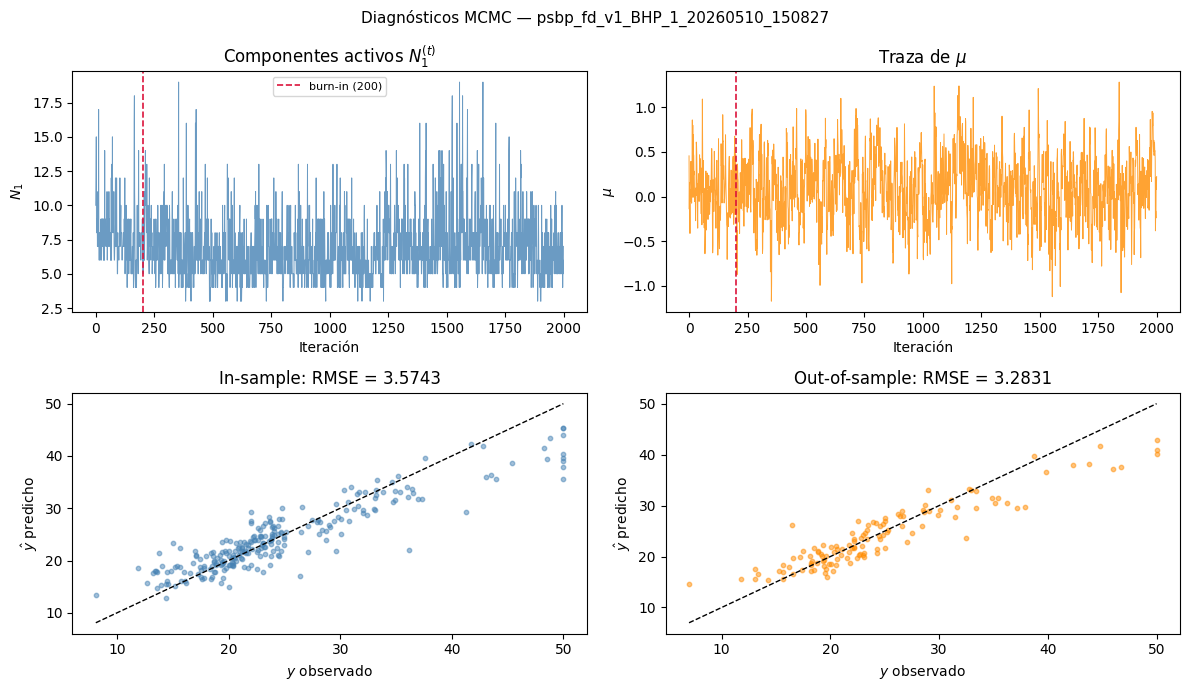

In [7]:
import matplotlib.pyplot as plt

burn = MCMC_CONFIG["burn"]
nsim = MCMC_CONFIG["nsim"]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle(f"Diagnósticos MCMC — {EXPERIMENT_ID}", fontsize=11)

# (a) Número de componentes activos
ax = axes[0, 0]
ax.plot(traces["N1out"], color="steelblue", lw=0.7, alpha=0.8)
ax.axvline(burn, color="crimson", lw=1.2, ls="--", label=f"burn-in ({burn})")
ax.set_title("Componentes activos $N_1^{(t)}$")
ax.set_xlabel("Iteración"); ax.set_ylabel("$N_1$")
ax.legend(fontsize=8)

# (b) Traza de mu
ax = axes[0, 1]
ax.plot(traces["muout"], color="darkorange", lw=0.7, alpha=0.8)
ax.axvline(burn, color="crimson", lw=1.2, ls="--")
ax.set_title(r"Traza de $\mu$")
ax.set_xlabel("Iteración"); ax.set_ylabel(r"$\mu$")

# (c) Predicciones in-sample vs valores reales
ax = axes[1, 0]
ax.scatter(y1, in_pred, s=10, alpha=0.5, color="steelblue")
lims = [min(y1.min(), in_pred.min()), max(y1.max(), in_pred.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set_title(f"In-sample: RMSE = {in_rmse:.4f}")
ax.set_xlabel("$y$ observado"); ax.set_ylabel(r"$\hat{y}$ predicho")

# (d) Predicciones out-of-sample vs valores reales
ax = axes[1, 1]
ax.scatter(y2, out_pred, s=10, alpha=0.5, color="darkorange")
lims = [min(y2.min(), out_pred.min()), max(y2.max(), out_pred.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set_title(f"Out-of-sample: RMSE = {out_rmse:.4f}")
ax.set_xlabel("$y$ observado"); ax.set_ylabel(r"$\hat{y}$ predicho")

plt.tight_layout()

path_fig = PATHS["reports"] / EXPERIMENT_ID / f"{EXPERIMENT_ID}_diagnostics.png"
fig.savefig(path_fig, dpi=150, bbox_inches="tight")
print(f"[OK] Figura guardada → {path_fig.relative_to(PROJECT_ROOT)}")
plt.show()

[OK] Inclusión  → reports\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_inclusion_probs.png


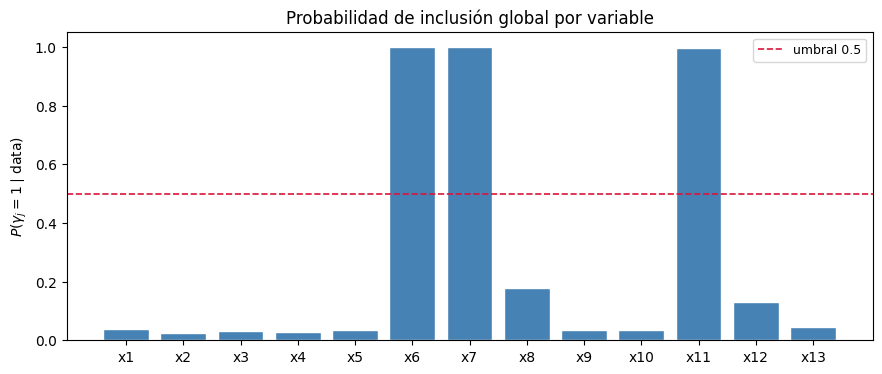

In [8]:
# ── Probabilidades de inclusión por variable ────────────────────────────────
p = model.n_features_
incl = incl_probs.to_numpy()

fig, ax = plt.subplots(figsize=(max(5, p * 0.8), 4))
ax.bar(range(p), incl, color="steelblue", edgecolor="white")
ax.axhline(0.5, color="crimson", lw=1.2, ls="--", label="umbral 0.5")
ax.set_xticks(range(p))
ax.set_xticklabels(model.feature_names_, rotation=0)
ax.set_ylim(0, 1.05)
ax.set_title("Probabilidad de inclusión global por variable")
ax.set_ylabel(r"$P(\gamma_j = 1 \mid \mathrm{data})$")
ax.legend(fontsize=9)

path_incl = PATHS["reports"] / EXPERIMENT_ID / f"{EXPERIMENT_ID}_inclusion_probs.png"
fig.savefig(path_incl, dpi=150, bbox_inches="tight")
print(f"[OK] Inclusión  → {path_incl.relative_to(PROJECT_ROOT)}")
plt.show()

## 6. Resumen del experimento

In [9]:
print("=" * 60)
print(f"  RESUMEN EXPERIMENTO: {EXPERIMENT_ID}")
print("=" * 60)
print(f"  Datos train  : {PATH_IN.name}  (n = {len(df_train)})")
print(f"  Datos test   : {PATH_OUT.name} (n2 = {len(df_test)})")
print(f"  Covariables  : p = {model.n_features_}")
print(f"  MCMC         : {MCMC_CONFIG['nsim']} iter, burn-in = {MCMC_CONFIG['burn']}")
print(f"  N trunc.     : {MCMC_CONFIG['N']}    Grilla M : {MCMC_CONFIG['M']}")
print(f"  Seed         : {SEED}")
print("-" * 60)
print(f"  inRMSE       : {in_rmse:.6f}")
print(f"  outRMSE      : {out_rmse:.6f}")
print("-" * 60)
print("  Artefactos guardados:")
print(f"    {path_npz.relative_to(PROJECT_ROOT)}")
print(f"    {path_pkl.relative_to(PROJECT_ROOT)}")
print(f"    {path_json.relative_to(PROJECT_ROOT)}")
print(f"    {path_pred.relative_to(PROJECT_ROOT)}")
print("  Reportes:")
print(f"    {path_fig.relative_to(PROJECT_ROOT)}")
print(f"    {path_incl.relative_to(PROJECT_ROOT)}")
print("=" * 60)

  RESUMEN EXPERIMENTO: psbp_fd_v1_BHP_1_20260510_150827
  Datos train  : BHPin_1.txt  (n = 249)
  Datos test   : BHPout_1.txt (n2 = 125)
  Covariables  : p = 13
  MCMC         : 2000 iter, burn-in = 200
  N trunc.     : 20    Grilla M : 50
  Seed         : 42
------------------------------------------------------------
  inRMSE       : 3.574302
  outRMSE      : 3.283096
------------------------------------------------------------
  Artefactos guardados:
    artefact\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_traces.npz
    artefact\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_results.pkl
    artefact\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_meta.json
    data\simulaciones\processed\predict\psbp_fd_v1_BHP_1_20260510_150827_predictions.npz
  Reportes:
    reports\simulaciones\psbp_fd_v1_BHP_1_20260510_150827\psbp_fd_v1_BHP_1_20260510_150827_diagnostics.png
    reports\simulaciones\